# Y($\pi$) on the Novera chip -- exact frame rotation of X($\pi$) [Novera]

`solve_mode="rotate_from_x"`: every arm here **is** `Xpi_novera`'s solved arm with the
drive phase advanced by $\phi_{\rm axis}=\pi/2$ -- not a second optimization (see
`gatespec.py`'s module docstring for the covariance argument, and
`proposals/Novera_work/README.md` §3). This notebook is deliberately short: it shows the
rotated waveforms and then spends its budget on `check_covariance.py Ypi_novera`, which
verifies the claim numerically rather than re-deriving it. If this needed more than a
page, the symmetry argument would have broken -- that would be the finding.

⚠️ Device check first, same as the X($\pi$) notebook: never fall back to the package
default device.

In [1]:
import sys, subprocess
from pathlib import Path

import matplotlib.pyplot as plt

_gate_dir = Path.cwd().parent / "gates" / "Novera_Ypi"
assert _gate_dir.exists(), f"run this notebook from Novera_work/notebooks/ (looked for {_gate_dir})"
sys.path.insert(0, str(_gate_dir))
import armlib as al

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True, "figure.facecolor": "white"})

DEV = al.DEV
assert DEV.anharmonicity == -0.19848, DEV.anharmonicity

print(f"gate = {al.spec.name}   phi_axis = {al.phi_axis:.6f} rad   "
      f"source = {al.spec.source_key}")
print(f"T = {al.T:g} ns   M = {DEV.n_modes}   decoh floor = {DEV.decoherence_floor:.4e}")

<string>:12: UserWarning: leakage-resonant harmonic n* = 2*T*|alpha| = 19.848 != n_modes = 20: the C4 spectral zero no longer lands on a basis harmonic (device.GROUPS, _plan_full_cost.md 2.6). This is allowed -- it is a design choice, not an error -- but any C4 claim from this device needs the mismatch stated.


gate = Y(pi) [Novera]   phi_axis = 1.570796 rad   source = Xpi_novera
T = 50 ns   M = 20   decoh floor = 6.3587e-04


## Rotated waveforms

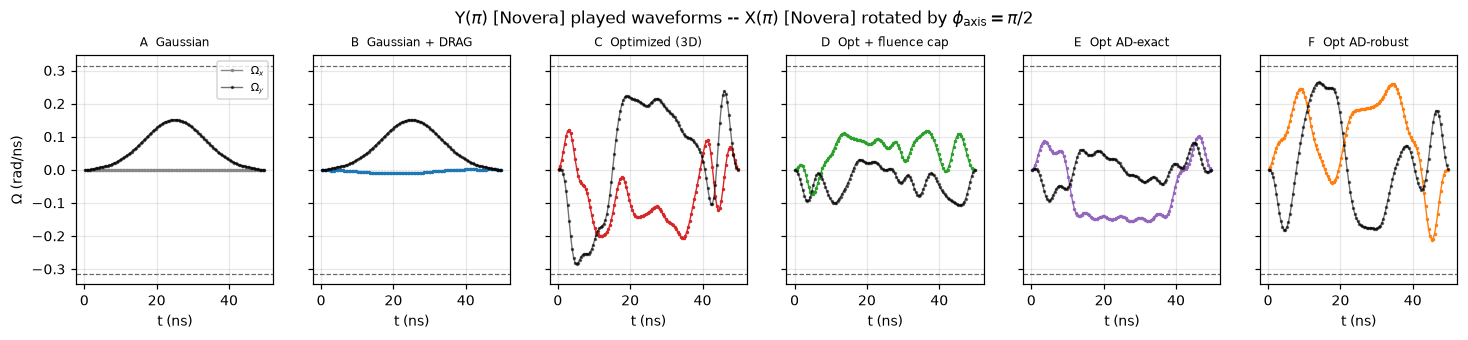

In [2]:
from curve_opt import geometry

arms = al.build_arms()
t_awg, _ = geometry.midpoint_grid(al.T, al.N_EXPORT)

fig, axes = plt.subplots(1, len(al.ARM_ORDER), figsize=(2.7 * len(al.ARM_ORDER), 2.7),
                         sharex=True, sharey=True)
for ax, k in zip(axes, al.ARM_ORDER):
    ox, oy = al.broadcast_of(arms[k], al.N_EXPORT)
    ax.plot(t_awg, ox, ".-", ms=2.5, lw=0.9, color=al.ARM_COLORS[k], label=r"$\Omega_x$")
    ax.plot(t_awg, oy, ".-", ms=2.5, lw=0.9, color="k", alpha=0.55, label=r"$\Omega_y$")
    for s in (+1, -1):
        ax.axhline(s * DEV.rabi_max_rate, ls="--", lw=0.8, color="0.4")
    ax.set_title(f"{k}  {arms[k].name}", fontsize=8)
    ax.set_xlabel("t (ns)")
axes[0].set_ylabel(r"$\Omega$ (rad/ns)")
axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle(r"Y($\pi$) [Novera] played waveforms -- X($\pi$) [Novera] rotated by "
            r"$\phi_{\rm axis}=\pi/2$", y=1.03)
plt.show()

## `check_covariance.py Ypi_novera --device configs/device_novera.json`

In [3]:
repo_root = Path.cwd().parents[1]
script = repo_root / "proposals" / "_gatelib" / "check_covariance.py"
device_cfg = repo_root / "configs" / "device_novera.json"

result = subprocess.run(
    [sys.executable, str(script), "Ypi_novera", "--device", str(device_cfg)],
    capture_output=True, text=True, cwd=repo_root)
print(result.stdout)
if result.stderr:
    print("--- stderr ---")
    print(result.stderr)
print(f"returncode = {result.returncode}")
assert result.returncode == 0, "check_covariance.py Ypi_novera did not PASS"


=== Y(pi) [Novera]  vs  its source gate  (pass: |diff| <= 1e-13 + 1e-08 |ref|) ===
arm A: 1-Fbar 1.745459e-03 vs 1.745459e-03  (abs 1.0e-14, rel 5.8e-12)
        sweep max abs 3.7e-15 (rel 4.3e-12)   cost rel diffs  c1:0.0e+00  c2:0.0e+00  c3:0.0e+00  c4:1.8e-14
        phi_vz refit spread 2.0e-08 rad (not part of the verdict -- see covariance_check's docstring)
arm B: 1-Fbar 7.454934e-06 vs 7.454934e-06  (abs 8.0e-15, rel 1.1e-09)
        sweep max abs 2.1e-15 (rel 2.2e-10)   cost rel diffs  c1:0.0e+00  c2:0.0e+00  c3:0.0e+00  c4:6.6e-13
        phi_vz refit spread 8.3e-09 rad (not part of the verdict -- see covariance_check's docstring)
arm C: 1-Fbar 6.567624e-05 vs 6.567624e-05  (abs 3.4e-15, rel 5.2e-11)
        sweep max abs 2.4e-15 (rel 1.8e-11)   cost rel diffs  c1:0.0e+00  c2:0.0e+00  c3:0.0e+00  c4:3.5e-12
        phi_vz refit spread 2.7e-08 rad (not part of the verdict -- see covariance_check's docstring)
arm D: 1-Fbar 4.453709e-06 vs 4.453709e-06  (abs 3.9e-15, rel 8.7e-10)


## What this says

`check_covariance.py` reports every arm's true $1-\bar F$, the whole $(\delta_z,
\epsilon)$ sweep and $C_1$–$C_4$ against the source gate's, arm by arm, and exits
non-zero the moment any of them is out of tolerance. It printed `PASS` above with
every relative cost difference at machine precision -- the rotation is exact on this
device too, exactly as it is on the default one.